# Simple Linear Regression
A step-by-step walkthrough of the linear regression from `main.py`: load `counting-data.csv`, do a train/test split, fit a line with `np.polyfit`, and plot the result.

## 1. Import Required Libraries
pandas for loading the CSV, NumPy for the fit, Matplotlib for plotting.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV_PATH = Path("counting-data.csv")

## 2. Load the Data
Read `counting-data.csv` and take a quick look. Each row has a `Number` and the `NextNumber` that followed it.

In [9]:
data = pd.read_csv(CSV_PATH)
print(f"{len(data)} rows")
data.head()

6 rows


,Number,NextNumber
0,0,1
1,1,2
2,3,4
3,100,101
4,115,116


## 3. Train/Test Split
A "poor man's" 80/20 split: shuffle the rows with a fixed seed (so it's reproducible), take the first 80% for training, and hold out the rest for testing. The line will be fit on the training rows only.

In [10]:
train = data.sample(frac=0.8, random_state=42)
test = data.drop(train.index)

x_train = train["Number"].to_numpy()
y_train = train["NextNumber"].to_numpy()
x_test = test["Number"].to_numpy()
y_test = test["NextNumber"].to_numpy()

print(f"train: {len(train)} rows, test: {len(test)} rows")

train: 5 rows, test: 1 rows


## 4. Fit the Line
Fit $y = mx + b$ on the training data with `np.polyfit(..., 1)` — degree 1 means linear. It returns the slope $m$ and intercept $b$ that minimize squared error (least squares).

In [11]:
m, b = np.polyfit(x_train, y_train, 1)
print(f"Fitted line: y = {m:.4f}x + {b:.4f}")

Fitted line: y = 1.0000x + 1.0000


## 5. Plot the Result
Scatter the train and test points, then draw the fitted line extended 100 units past the min/max of x in both directions. The test points (which the fit never saw) show how well the line generalizes.

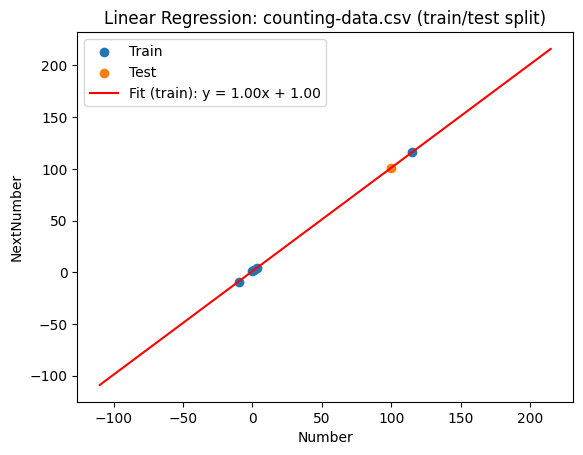

In [12]:
x_all = data["Number"].to_numpy()
line_x = np.array([x_all.min() - 100, x_all.max() + 100])
line_y = m * line_x + b

plt.scatter(x_train, y_train, label="Train")
plt.scatter(x_test, y_test, label="Test")
plt.plot(line_x, line_y, color="red", label=f"Fit (train): y = {m:.2f}x + {b:.2f}")

plt.xlabel("Number")
plt.ylabel("NextNumber")
plt.title("Linear Regression: counting-data.csv (train/test split)")
plt.legend()
plt.show()